# Telco Customer Churn — Feature Engineering
**Goal:** Transform the cleaned data into a format the ML model can learn from.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Load the cleaned data (repeat cleaning steps from EDA)
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df[df['TotalCharges'].notnull()].reset_index(drop=True)
df.drop(columns=['customerID'], inplace=True)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print('Data loaded and cleaned.')
print('Shape:', df.shape)

Data loaded and cleaned.
Shape: (7032, 20)


## 1. Identify Column Types

In [2]:
# Separate columns by type
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
target_col = 'Churn'
categorical_cols = [col for col in df.columns if col not in numerical_cols + [target_col]]

print('Numerical columns:', numerical_cols)
print(f'\nCategorical columns ({len(categorical_cols)}):')
for col in categorical_cols:
    print(f'  {col}: {df[col].unique()}')

Numerical columns: ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns (16):
  gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
  SeniorCitizen: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
  Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
  Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
  PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
  MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
  InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
  OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
  OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
  DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
  TechSupport: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
  StreamingTV: <StringArray>
['No', 'Yes', 'No interne

## 2. Encode Categorical Columns

In [3]:
# Binary columns (only 2 unique values) — use Label Encoding (0 and 1)
binary_cols = [col for col in categorical_cols if df[col].nunique() == 2]
print('Binary columns (Label Encoding):', binary_cols)

df_encoded = df.copy()
le = LabelEncoder()

for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Also encode the target column
df_encoded['Churn'] = le.fit_transform(df_encoded['Churn'])  # No=0, Yes=1

print('\nChurn encoding: No=0, Yes=1')
print(df_encoded['Churn'].value_counts())

Binary columns (Label Encoding): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']



Churn encoding: No=0, Yes=1
Churn
0    5163
1    1869
Name: count, dtype: int64


In [4]:
# Multi-value columns (more than 2 unique values) — use One-Hot Encoding
multi_cols = [col for col in categorical_cols if df[col].nunique() > 2]
print('Multi-value columns (One-Hot Encoding):', multi_cols)

df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, drop_first=True)

print('\nShape after encoding:', df_encoded.shape)
print('\nAll columns after encoding:')
print(list(df_encoded.columns))

Multi-value columns (One-Hot Encoding): ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

Shape after encoding: (7032, 31)

All columns after encoding:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMet

## 3. Scale Numerical Columns

In [5]:
# Check the range of numerical columns before scaling
print('Before scaling:')
print(df_encoded[numerical_cols].describe().round(2))

scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print('\nAfter scaling:')
print(df_encoded[numerical_cols].describe().round(2))

Before scaling:
        tenure  MonthlyCharges  TotalCharges
count  7032.00         7032.00       7032.00
mean     32.42           64.80       2283.30
std      24.55           30.09       2266.77
min       1.00           18.25         18.80
25%       9.00           35.59        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.86       3794.74
max      72.00          118.75       8684.80

After scaling:
        tenure  MonthlyCharges  TotalCharges
count  7032.00         7032.00       7032.00
mean     -0.00            0.00         -0.00
std       1.00            1.00          1.00
min      -1.28           -1.55         -1.00
25%      -0.95           -0.97         -0.83
50%      -0.14            0.18         -0.39
75%       0.92            0.83          0.67
max       1.61            1.79          2.82


## 4. Split into Features and Target

In [6]:
# X = features (everything the model learns FROM)
# y = target (what the model is trying to PREDICT)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print('Features (X) shape:', X.shape)
print('Target (y) shape:', y.shape)
print('\nTarget distribution:')
print(y.value_counts())
print(f'\nChurn rate: {y.mean()*100:.1f}%')

Features (X) shape: (7032, 30)
Target (y) shape: (7032,)

Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn rate: 26.6%


## 5. Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing, 80% for training
    random_state=42,     # ensures same split every time you run it
    stratify=y           # keeps same churn ratio in both splits
)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)
print(f'\nChurn rate in training set: {y_train.mean()*100:.1f}%')
print(f'Churn rate in test set: {y_test.mean()*100:.1f}%')

Training set size: (5625, 30)
Test set size: (1407, 30)

Churn rate in training set: 26.6%
Churn rate in test set: 26.6%


## 6. Visualise Class Imbalance

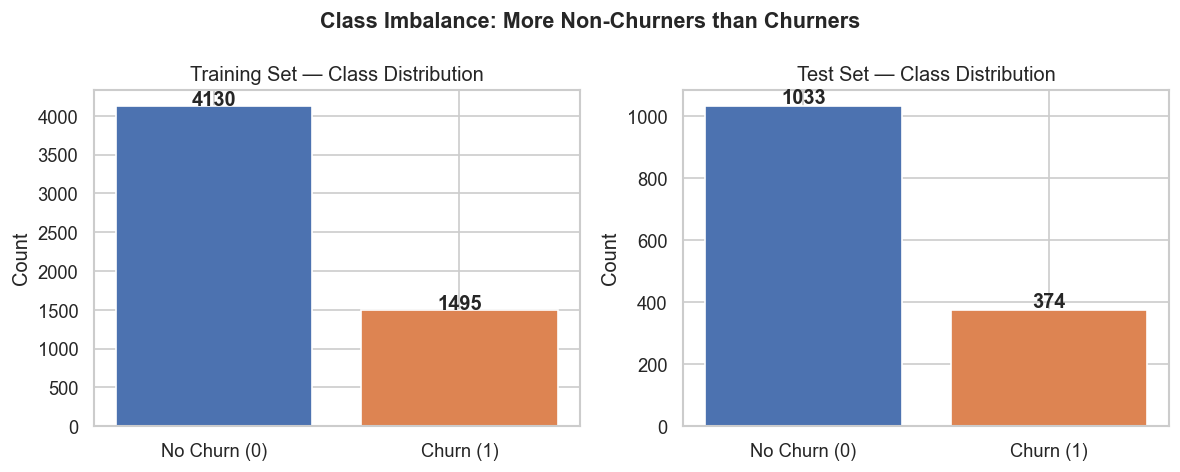


Note: ~73% No Churn vs ~27% Churn — this is class imbalance.
We will handle this in the modelling step.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Training set
train_counts = y_train.value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], train_counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Training Set — Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Test set
test_counts = y_test.value_counts()
axes[1].bar(['No Churn (0)', 'Churn (1)'], test_counts.values, color=['#4C72B0', '#DD8452'])
axes[1].set_title('Test Set — Class Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Imbalance: More Non-Churners than Churners', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/06_class_imbalance.png', bbox_inches='tight')
plt.show()

print('\nNote: ~73% No Churn vs ~27% Churn — this is class imbalance.')
print('We will handle this in the modelling step.')

## 7. Save Processed Data

In [9]:
import os
os.makedirs('../outputs', exist_ok=True)

X_train.to_csv('../outputs/X_train.csv', index=False)
X_test.to_csv('../outputs/X_test.csv', index=False)
y_train.to_csv('../outputs/y_train.csv', index=False)
y_test.to_csv('../outputs/y_test.csv', index=False)

print('Processed data saved to outputs/')
print('Ready for modelling.')

Processed data saved to outputs/
Ready for modelling.
